# Tutorial: 3-Exact Steiner Algorithm for Bounded Edge Length

This notebook demonstrates the **3-Exact Steiner Algorithm** (Algorithm B) as proposed in the paper:
> **"An efficient 3-approximation algorithm for the Steiner tree problem with the minimum number of Steiner points and bounded edge length"**  
> *Donghoon Shin & Sunghee Choi (2023)*

## Problem Definition
Given three terminal points $p_a, p_b, p_c$ and a maximum edge length $R$, find a Steiner junction point $p_J$ that minimizes the total number of Steiner points required to connect the three terminals, such that every edge in the resulting 3-star tree has length $\le R$.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from graph_tools import *

# Import utilities from our standalone module
from steiner_3exact import *
from geometry_utils import *
from graph_tools import *

## Step 1: Initialize Terminals
We define three points forming a triangle. If the triangle is non-obtuse ($< 120^\circ$), a 3-star junction is likely to provide a better solution than a simple Steinerized MST (Wedge).

Terminals: A(1.75, 1.2), B(0.0, 0.0), C(3.5, 0.0)
R (Max edge length): 2.0


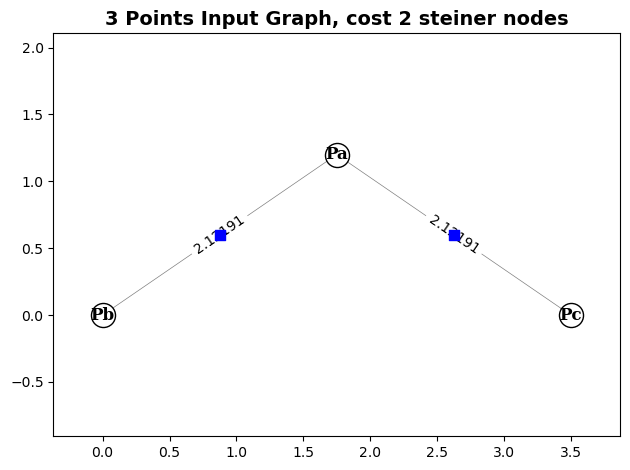

In [32]:
# Define terminals
pa = (0.0, 5.0)
pb = (-4.0, 0.0)
pc = (4.0, 0.0)

pa = (1.75, 1.2)
pb = (0.0, 0.0)
pc = (3.5, 0.0)

# Maximum distance constraint
R = 2.0

print(f"Terminals: A{pa}, B{pb}, C{pc}")
print(f"R (Max edge length): {R}")

G = setup_three_point_graph(pa, pb, pc)
st_nodes = calc_steinernize_MST(pa, pb, pc, R)

draw_point(G, f"3 Points Input Graph, cost {len(st_nodes)} steiner nodes", extra_points=st_nodes, show_edge_label=True, show_edges=True)


## Step 2: Find the Fermat Point
The Fermat point ($p_F$) is the point that minimizes the sum of Euclidean distances to the three vertices. In the classical Steiner Tree problem (without length constraints), this is the optimal junction location.

Fermat Point: (1.7500, 1.0104)


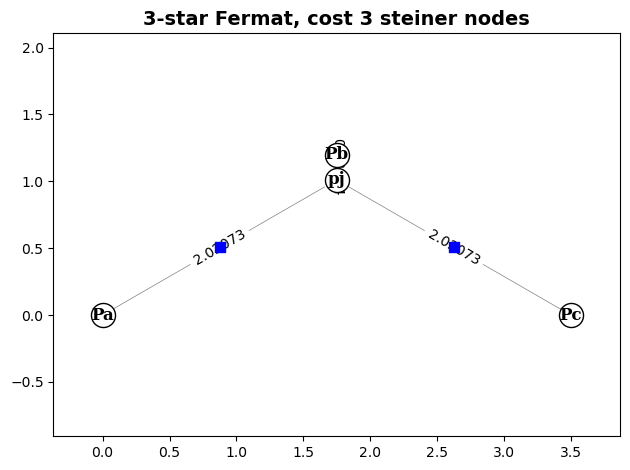

In [29]:
pf = find_fermat_point(pa, pb, pc)
if pf:
    print(f"Fermat Point: ({pf[0]:.4f}, {pf[1]:.4f})")
    G = setup_three_star_graph(pa, pb, pc, pj=pf)
    st_nodes_count, st_nodes = calc_steinernize_3ST(pa, pb, pc, pf, R)
else:
    print("No Fermat point found.")
    st_nodes_count = len(st_nodes)

draw_point(G, f"3-star Fermat, cost {st_nodes_count} steiner nodes", extra_points=st_nodes, show_edge_label=True, show_edges=True) 

## Step 3: Solve Equation (6) Optimization
The Paper introduces an exact algorithm that finds the optimal junction $p_J$ in constant time. 

### How it works:
1. **Normalization**: The triangle is rotated and scaled so $p_b = (0,0)$ and $p_c = (1,0)$.
2. **Steinerized Counts**: We calculate the "Steinerized count" (number of segments) from the junction to each terminal. Let these be $i, j, k$.
3. **Equation (6)**: A quartic polynomial is solved to determine the candidate values for the junction placement that satisfy the cost minimization objective.
4. **Discrete Search**: We check a small set of 8 Parameter configurations based on the Fermat point's hop counts to find the absolute minimum.

Sequence: pa, pb, pc, i_f: 1, j_f: 2, k_f: 2, t_base: 3
======== Param: -1 2 2 ========
pb: (0.00, 0.00), pc: (3.50, 0.00) Ci: 1, Cj: 1, Ck: 1
Current Best: inf << New Best: 1
Optimal Junction found: (1.7500, 0.9682)
Minimum Steiner points required: 1


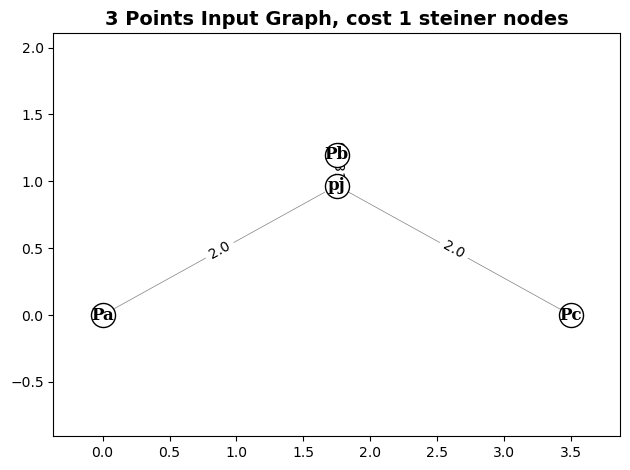

In [30]:
# Execute the 3-exact solver
opt_cost, pj, opt_found = solve_3exact_steiner(pa, pb, pc, R)
print("==================================")
if opt_found: 
    print(f"Optimal Junction found: ({pj[0]:.4f}, {pj[1]:.4f})")
    print(f"Minimum Steiner points required: {opt_cost}")
    G = setup_three_star_graph(pa, pb, pc, pj)
    st_nodes_count, st_nodes = calc_steinernize_3ST(pa, pb, pc, pj, R)
elif pf:
    print(f"Fermat graph is used: ({pf[0]:.4f}, {pf[1]:.4f})")
    print(f"Minimum Steiner points required: {opt_cost}")
    G = setup_three_star_graph(pa, pb, pc, pj)
    st_nodes_count, st_nodes = calc_steinernize_3ST(pa, pb, pc, pj, R)
else:
    print(f"wedge graph is used")

draw_point(G, f"3 Points Input Graph, cost {st_nodes_count} steiner nodes", extra_points=st_nodes, show_edge_label=True, show_edges=True) 


## Step 4: Full 3-Star Tree Visualization
Finally, we visualize the complete 3-star tree, including the intermediate Steiner points added along the edges to satisfy the length constraint $R$.

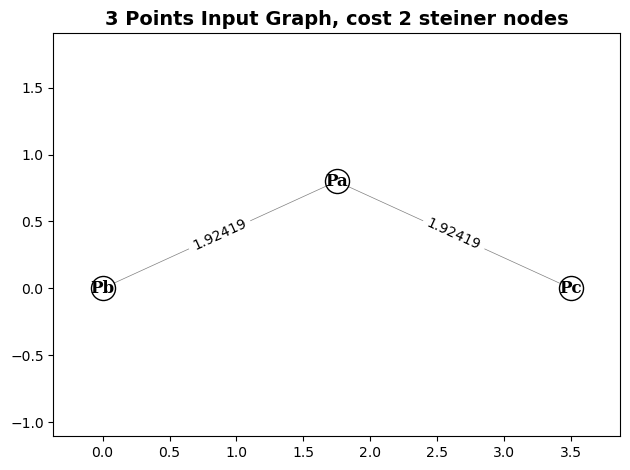